<a href="https://colab.research.google.com/github/takumi-maker/dmd/blob/main/UTC_prototype_bond1_2_sub.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from itertools import product
from scipy import stats

class Trader:
  ACTIVATION_FUNCTIONS = {
      'identity':lambda x: x,
      'tanh':    lambda x: np.tanh(x),
      'sinh':    lambda x: np.sinh(np.clip(x, -10, 10)),
      'relu':    lambda x: np.maximum(0, x),
  }

  BINARY_OPERATORS = {
      'add': lambda x, y: x + y,
      'sub': lambda x, y: x - y,
      'mul': lambda x, y: x * y,
      'proj_x': lambda x, y: x,
      'proj_y': lambda x, y: y,
      'max': lambda x, y: np.maximum(x, y),
      'min': lambda x, y: np.minimum(x, y),
      'gt': lambda x, y: (x > y).astype(float),
      'lt': lambda x, y: (x < y).astype(float),
      'corr': lambda x, y: np.sign(x) * np.sign(y),
  }

  def __init__(self, n_stocks: int, M: int = None, theta: dict = None,
               weight_mean: np.ndarray = None,
               weight_cov: np.ndarray = None,
               sigma0: float = 1.0,
               window: int = 10):
    self.n_stocks = n_stocks
    self.sigma0 = sigma0
    self.window = window

    activation_keys = list(self.ACTIVATION_FUNCTIONS.keys())
    operator_keys = list(self.BINARY_OPERATORS.keys())

    if theta is None:
      self.M = M if M is not None else np.random.randint(1, 6)
      self.P = np.random.randint(0, n_stocks, self.M)
      self.Q = np.random.randint(0, n_stocks, self.M)
      self.D = np.random.randint(0,self.window+1, self.M)
      self.F = np.random.randint(0,self.window+1, self.M)
      self.O = [np.random.choice(operator_keys) for _ in range(self.M)]
      self.A = [np.random.choice(activation_keys) for _ in range(self.M)]
    else:
      self.M = theta['M']
      self.P = theta['P']
      self.Q = theta['Q']
      self.D = theta['D']
      self.F = theta['F']
      self.O = theta['O']
      self.A = theta['A']

    self.weight_mean = (weight_mean if weight_mean is not None else np.random.rand(self.M))
    self.weight_cov = (weight_cov if weight_cov is not None else np.eye(self.M) * sigma0**2)

  def _compute_features(self, returns: np.ndarray) -> np.ndarray:
    n_stocks, T = returns.shape
    z = np.zeros(self.M)
    #print("T",T)
    for j in range(self.M):
      p, q = self.P[j], self.Q[j]
      d, f = self.D[j], self.F[j]
      #print(q)
      t_d = T -1 -d
      t_f = T -1 -f
      #print(t_d)
      #print(t_f)
      if t_d < 0 or t_f < 0:
        z[j] = 0.0
        continue

      rp = returns[p, t_d]
      rq = returns[q, t_f]

      op_fn = self.BINARY_OPERATORS[self.O[j]]
      act_fn = self.ACTIVATION_FUNCTIONS[self.A[j]]

      val = op_fn(rp, rq)
      val = act_fn(val)
      #print(val)
      if not np.isfinite(val):
        val = 0.0

      z[j] = val

    return z

  def predict(self, returns: np.ndarray):

    z = self._compute_features(returns)
    mu = self.weight_mean @ z
    sigma2 = float(z @ self.weight_cov @ z)
    sigma2 = max(sigma2, 1e-10)
    #print("mu",mu)
    return mu , sigma2, z

  def cumulative_return(self, returns: np.ndarray,
                        target_returns: np.ndarray,
                        windows: int = 10):
    T = returns.shape[1]
    cumret = 0.0
    #print(target_returns)
    #print(T)
    for t in range(len(target_returns)):
      #print(self.weight_mean)

      r_window = returns[:, t:t+windows]
      #print(r_window)
      z = self._compute_features(r_window)
      #print(z)
      pred = self.weight_mean @ z
      cumret += target_returns[t] * np.sign(pred)
    return cumret

  def update_weights_map(self, returns: np.ndarray,
                         target_returns: np.ndarray,
                         sigma2_noise: float = 0.01,
                         windows: int = 10):
    T = returns.shape[1]
    Z_list, y_list = [], []

    for t in range(len(target_returns)):
      r_window = returns[:, t:t+windows]
      z = self._compute_features(r_window)
      Z_list.append(z)
      if t < len(target_returns):
        y_list.append(target_returns[t])

    if len(y_list) == 0:
      return

    Z = np.array(Z_list[:len(y_list)])
    y = np.array(y_list)
    lam = sigma2_noise / (self.sigma0**2)
    A_mat = Z.T @ Z + lam * np.eye(self.M)

    try:
      A_inv = np.linalg.inv(A_mat)
    except np.linalg.LinAlgError:
      A_inv = np.linalg.pinv(A_mat)

    self.weight_mean = A_inv @ Z.T @ y

    self.weight_cov = A_inv * sigma2_noise

  def get_theta(self) -> dict:
    return {
        'M': self.M,'P': self.P.copy(),'Q': self.Q.copy(),
        'D': self.D.copy(),'F': self.F.copy(),
        'O': list(self.O), 'A': list(self.A),
    }

  def clone(self) -> 'Trader':
    new_trader = Trader(
        n_stocks=self.n_stocks,
        theta=self.get_theta(),
        weight_mean=self.weight_mean.copy(),
        weight_cov=self.weight_cov.copy(),
        sigma0=self.sigma0,
    )
    return new_trader

In [ ]:
import numpy as np
from sklearn.mixture import GaussianMixture


class Company:

  def __init__(self, n_stocks: int, N: int = 200,
               P: float = 0.1,
               Q: float = 0.1, F: int = 1,
               sigma0: float = 1.0,
               sigma2_noise: float = 0.01,
               window0: int = 10
               ):
    self.n_stocks   =  n_stocks
    self.N          =  N
    self.P          =  P
    self.Q          =  Q
    self.F          =  F
    self.sigma0     =  sigma0
    self.sigma2_noise  =  sigma2_noise
    self.window0     =  window0
    self.traders  = [
        Trader(n_stocks=n_stocks, sigma0=sigma0,window=window0)
        for _ in range(N)
    ]


  def predict(self, returns: np.ndarray):

    mus, sigma2s = [], []

    for trader in self.traders:
      mu_n, sigma2_n, _ = trader.predict(returns)
      #print("mu_n",mu_n)
      mus.append(mu_n)
      sigma2s.append(sigma2_n)

    mus     = np.array(mus)
    sigma2s = np.array(sigma2s)

    mu = np.mean(mus)
    sigma2_intra = np.mean((mus - mu)**2)
    sigma2_inter = np.mean(sigma2s)

    sigma = np.sqrt(sigma2_intra + sigma2_inter)

    return mu, sigma

  def educate(self, returns: np.ndarray,
              target_returns: np.ndarray,
              windows: int = 10):
    #print(self.traders)
    cum_returns = np.array([
        trader.cumulative_return(returns, target_returns,windows=windows)
        for trader in self.traders
        ])

    threshold = np.percentile(cum_returns, self.Q*100)

    for i, trader in enumerate(self.traders):
      if cum_returns[i] <= threshold:
        trader.update_weights_map(
            returns, target_returns, self.sigma2_noise, windows=windows
        )

  def fire_and_hire(self, returns: np.ndarray,
                    target_returns: np.ndarray,
                    windows: int = 10):

    for _ in range(self.F):
      cum_returns = np.array([
          trader.cumulative_return(returns, target_returns,windows=windows)
          for trader in self.traders
      ])

      threshold = np.percentile(cum_returns, (1-self.P)*100)
      threshold_bad = np.percentile(cum_returns, self.P*100)

      good_traders = [
          t for t, r in zip(self.traders, cum_returns)
          if r > threshold
      ]

      bad_traders = [
          t for t, r in zip(self.traders, cum_returns)
          if r < threshold_bad
      ]

      normal_traders = [
          t for t, r in zip(self.traders, cum_returns)
          if r >= threshold_bad
      ]

      if len(good_traders) < 1:
        self.traders = [
            Trader(n_stocks=self.n_stocks, sigma0=self.sigma0,window=self.window0)
            for _ in range(self.N)
        ]
        return
      new_traders = self._generate_traders_from_gmm(
          good_traders, len(bad_traders)
      )

      normal_traders.extend(new_traders)
      #print(normal_traders)
      #print(len(normal_traders))
      self.traders = normal_traders

  def _generate_traders_from_gmm(self, good_traders: list, n_generate: int) -> list:

    param_vectors = []
    #param_vectors2 = []
    for t in good_traders:
      param_vectors.append(t.weight_mean)
      #param_vectors2.append(t.weight_cov)
    #print("param_vectors2",param_vectors2)
    #param_array = np.array(param_vectors)いらなさそう
    #for v in param_vectors:
      #print("v",v)

    max_dim = max(v.shape[0] for v in param_vectors)
    #max_dim2 = max(v.shape[0] for v in param_vectors2)
    padded = np.zeros((len(param_vectors), max_dim))
    #padded2 = np.zeros((len(param_vectors2), max_dim2))
    for i, v in enumerate(param_vectors):
      padded[i, :v.shape[0]] = v
    #for i, v in enumerate(param_vectors2):
      #padded2[i, :v.shape[0]] = v
    #print("padded",padded)

    n_components = max(1, min(len(good_traders) // 3, 5))

    try:
      gmm = GaussianMixture(
          n_components=n_components,
          covariance_type='full',
          max_iter=100
      )
      gmm.fit(padded)
      gmm2 = GaussianMixture(
          n_components=n_components,
          covariance_type='full',
          max_iter=100,
          random_state=42
      )
      #gmm2.fit(padded2)
    except Exception:
      return [
          Trader(n_stocks=self.n_stocks, sigma0=self.sigma0,window=self.window0)
          for _ in range(n_generate)
      ]

    new_traders = []
    random_generate = int(n_generate*0.2)
    for _ in range(n_generate-random_generate):
      parent = np.random.choice(good_traders)
      new_trader = parent.clone()

      sample, _ = gmm.sample(1)
      sample = sample[0]
      #print("sample",sample)
      dim = min(new_trader.M, len(sample))
      new_trader.weight_mean[:dim] = sample[:dim]
      new_traders.append(new_trader)

    for _ in range(random_generate):
      new_trader = Trader(n_stocks=self.n_stocks, sigma0=self.sigma0,window=self.window0)
      new_traders.append(new_trader)

    return new_traders

  def train(self, returns: np.ndarray,
            target_stock_idx: int = 0,
            window: int =10):

    n_stocks, T = returns.shape
    target_returns = returns[target_stock_idx, :]
    print(f"[Company.train] T={T}, window={window},N={self.N}")

    for t in range(window+1, T-1):


      if t % 10 == 0:
        try:
          r_window = returns[:, t-window-30:t-1]
        except:
          r_window = returns[:, t-window-10:t-1]
        try:
          y_window = target_returns[t-30:t]
        except:
          y_window = target_returns[t-10:t]

        self.educate(r_window, y_window,window)
        self.fire_and_hire(r_window, y_window,window)

      if t % 50 ==0:
        print(f"t={t}/{T-1}訓練中...")

In [ ]:
class UTCMethod:

  def __init__(self, n_stocks: int, N: int = 200,
               P: float = 0.1,
               Q: float = 0.1, F: int =1,
               sigma0: float = 1.0,
               sigma2_noise: float = 0.01,
               window: int = 10,
               lag: int = 0,
               uncertainty_threshold_percentile: float = 50.0
               ):
    self.n_stocks = n_stocks
    self.window = window
    self.lag = lag
    self.unc_thresh = uncertainty_threshold_percentile

    self.company = Company(
        n_stocks=n_stocks, N=N,P=P, Q=Q, F=F,
        sigma0=sigma0, sigma2_noise=sigma2_noise,
        window0=window
    )

    self.predicted_returns = []
    self.predicted_sigmas = []
    self.past_sigma2_history = []

  def fit(self, returns: np.ndarray, target_stock_idx: int = 0):
    self.target_stock_idx = target_stock_idx
    self.company.train(
        returns=returns,
        target_stock_idx=target_stock_idx,
        window=self.window
    )
    print("[UTCMethod] 訓練完了")

  def predict_one_step(self, returns: np.ndarray):
    mu, sigma = self.company.predict(returns)
    return mu, sigma

  def backtest(self, returns: np.ndarray,target_stock_idx: int = 0):

    n_stocks, T = returns.shape
    portfolio_returns = []
    sigma2_history = []
    target_returns = returns[target_stock_idx, :]

    print(f"[UTCMethod.backtest] T={T}, window={self.window}")

    for t in range(self.window + self.lag +1, T-1):
      r_window = returns[:, t-self.lag-self.window:t-self.lag]

      mus, sigmas = [], []
      for s in range(n_stocks):
        if s == target_stock_idx:
          mu_s, sigma_s = self.company.predict(r_window)
          mus.append(mu_s)
          sigmas.append(sigma_s)
      mus = np.array(mus)
      sigmas = np.array(sigmas)
      sigma2s = sigmas**2
      #print("sigma2",sigma2s)

      sigma2_history.append(sigma2s.copy())

      if len(sigma2_history) > 1:
        past_sigma2_mean = np.mean(
            np.array(sigma2_history[:-1]), axis=0
        )
        #print("past_sigma2_mean",past_sigma2_mean)
        threshold = np.percentile(
            sigma2_history, self.unc_thresh
        )
        if self.unc_thresh != 0.0:
          active_mask = sigma2s < threshold
        else:
          active_mask = np.ones(1, dtype=bool)
      else:
        active_mask = np.ones(1, dtype=bool)
      #print("active_mask",active_mask)
      #print("mus",mus)
      signals = np.sign(mus) * active_mask.astype(float)
      #print("signals",signals)
      actual_returns = returns[target_stock_idx, t+1]

      if np.sum(active_mask) > 0:
        R_t = np.mean(signals * actual_returns)
      else:
        R_t = 0.0

      portfolio_returns.append(R_t)

      if t % 10 == 0:
        try:
          r_window = returns[:, t-self.window-30:t-1]
        except:
          r_window = returns[:, t-self.window-10:t-1]
        try:
          y_window = target_returns[t-30:t]
        except:
          y_window = target_returns[t-10:t]
        self.company.educate(r_window, y_window,self.window)
        self.company.fire_and_hire(r_window, y_window,self.window)

    portfolio_returns = np.array(portfolio_returns)
    results = self._compute_metrics(portfolio_returns)

    return results, portfolio_returns

  def _compute_metrics(self, portfolio_returns: np.ndarray,
                       TY: int = 250) -> dict:
    T = len(portfolio_returns)

    AR = TY * np.mean(portfolio_returns)

    RISK = np.sqrt(TY) * np.std(portfolio_returns, ddof=1)

    SR = AR /RISK if RISK >1e-10 else 0.0

    cumulative = np.cumsum(portfolio_returns)

    MDD = 0.0
    for t in range(T):
      for s in range(t+1, T):
        dd = 1 - cumulative[t] / (cumulative[s] + 1e-10)
        MDD = max(MDD, dd)
    MDD = -MDD

    CR = AR /abs(MDD) if abs(MDD) > 1e-10 else 0.0

    return{
        'AR': AR, 'RISK': RISK, 'SR': SR,
        'MDD': MDD, 'CR': CR,
    }

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd

def experiment_market_simulation(train_T,target_stock_idx,n_traders: int = 20):

  np.random.seed(0)


  target_stock_idx = target_stock_idx
  df = pd.read_csv("債券複利データセット3.csv")
  df = df.drop(df.columns[0], axis=1)


  returns = (df - df.shift(1)).dropna()
  returns = returns.to_numpy()
  returns = returns.T
  T = len(returns[0])
  n_stocks = len(returns)



  train_T = train_T
  train_data = returns[:, :train_T]
  test_data = returns[:, train_T:]

  utc = UTCMethod(
      n_stocks= n_stocks,
      N=n_traders,
      P=0.1,
      Q=0.5,
      F=1,
      sigma0=1.0,
      sigma2_noise=0.01,
      window=30,
      lag=0,
      uncertainty_threshold_percentile=10.0
  )
  utc.fit(train_data, target_stock_idx=target_stock_idx)

  results_utc, port_utc = utc.backtest(test_data,target_stock_idx)

  utc_tc = UTCMethod(
      n_stocks=n_stocks,
      N=n_traders,
      P=0.1,
      Q=0.5,
      F=1,
      sigma0=1.0,
      sigma2_noise=0.01,
      window=30,
      lag=0,
      uncertainty_threshold_percentile=0.0
  )

  utc_tc.fit(train_data,target_stock_idx=target_stock_idx)
  results_tc, port_tc = utc_tc.backtest(test_data,target_stock_idx)

  market_returns = test_data[target_stock_idx,:]
  results_market = utc._compute_metrics(market_returns[utc.window+utc.lag:])

  print(f"{'指標':<8} {'UTC':>8} {'TC':>8} {'Market':>8}")
  print("-"*50)
  for key in ['AR', 'RISK', 'SR', 'MDD', 'CR']:
    print(f"{key:<8}"
          f"{results_utc.get(key, 0):>8.2f}"
          f"{results_tc.get(key, 0):>8.2f}"
          f"{results_market.get(key, 0):>8.2f}")
  print("="*50)

  fig, ax = plt.subplots(figsize=(12, 6))

  cum_utc = np.cumsum(port_utc)
  cum_tc = np.cumsum(port_tc)
  cum_market = np.cumsum(market_returns[utc.window+utc.lag:utc.window+utc.lag+len(port_utc)])

  t_axis = np.arange(len(cum_utc))
  ax.plot(t_axis, cum_utc, label='UTC')
  ax.plot(t_axis, cum_tc, label='TC')
  ax.plot(t_axis, cum_market, label='Market', linestyle='--')

  ax.set_title('Cumulative Portfolio Returns')
  ax.set_xlabel('Time')
  ax.set_ylabel('Cumulative Returns')
  ax.legend()
  ax.grid(True)

  plt.tight_layout()
  plt.show()


In [ ]:
df = pd.read_csv("債券複利データセット3.csv")
df = df.drop(df.columns[0], axis=1)
df
returns = (df - df.shift(1)).dropna()
returns
returns = returns.to_numpy()
returns = returns.T
print(returns.shape)
train_data = returns[:, :200]
train_data
#print(returns.shape)
#print(len(returns[0]))

(8, 1111)


array([[ 0.   ,  0.005, -0.006, ...,  0.   , -0.001,  0.005],
       [-0.005,  0.015,  0.   , ..., -0.004, -0.006, -0.001],
       [-0.004,  0.005,  0.   , ..., -0.014, -0.009, -0.001],
       ...,
       [-0.009,  0.005,  0.004, ...,  0.   , -0.005, -0.01 ],
       [-0.014,  0.008,  0.006, ...,  0.   ,  0.009, -0.001],
       [-0.017,  0.012,  0.009, ...,  0.   ,  0.014,  0.004]])

[Company.train] T=200, window=30,N=100
t=50/199訓練中...
t=100/199訓練中...
t=150/199訓練中...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


[UTCMethod] 訓練完了
[UTCMethod.backtest] T=911, window=30


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:

[Company.train] T=200, window=30,N=100
t=50/199訓練中...
t=100/199訓練中...
t=150/199訓練中...
[UTCMethod] 訓練完了
[UTCMethod.backtest] T=911, window=30


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


指標            UTC       TC   Market
--------------------------------------------------
AR          0.22    0.40    0.66
RISK        0.23    0.49    0.49
SR          0.98    0.81    1.36
MDD       -40.67-339998491.10   -1.00
CR          0.01    0.00    0.66


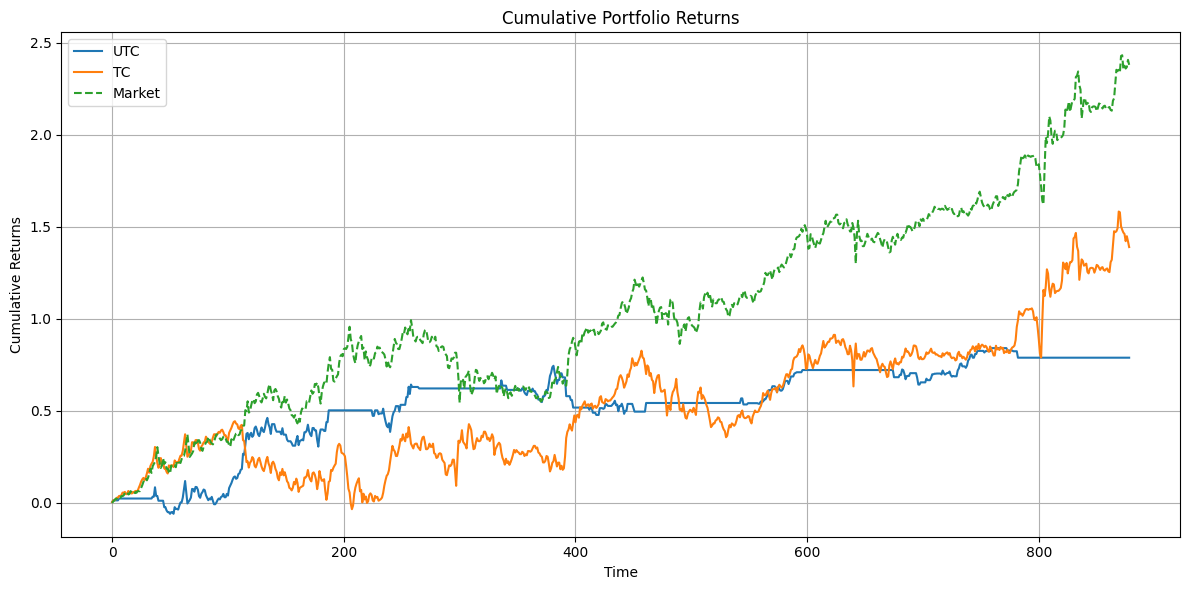

In [ ]:

experiment_market_simulation(train_T=200,target_stock_idx=6,n_traders=100)

train_T 200
[Company.train] T=200, window=30,N=100
t=50/199訓練中...
t=100/199訓練中...
t=150/199訓練中...
[UTCMethod] 訓練完了
[UTCMethod.backtest] T=911, window=30


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


[Company.train] T=200, window=30,N=100
t=50/199訓練中...
t=100/199訓練中...
t=150/199訓練中...
[UTCMethod] 訓練完了
[UTCMethod.backtest] T=911, window=30


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:

指標            UTC       TC   Market
--------------------------------------------------
AR         -0.00    0.06    0.58
RISK        0.10    0.47    0.47
SR         -0.00    0.13    1.24
MDD     -300002499.02 -441.00   -2.00
CR         -0.00    0.00    0.29


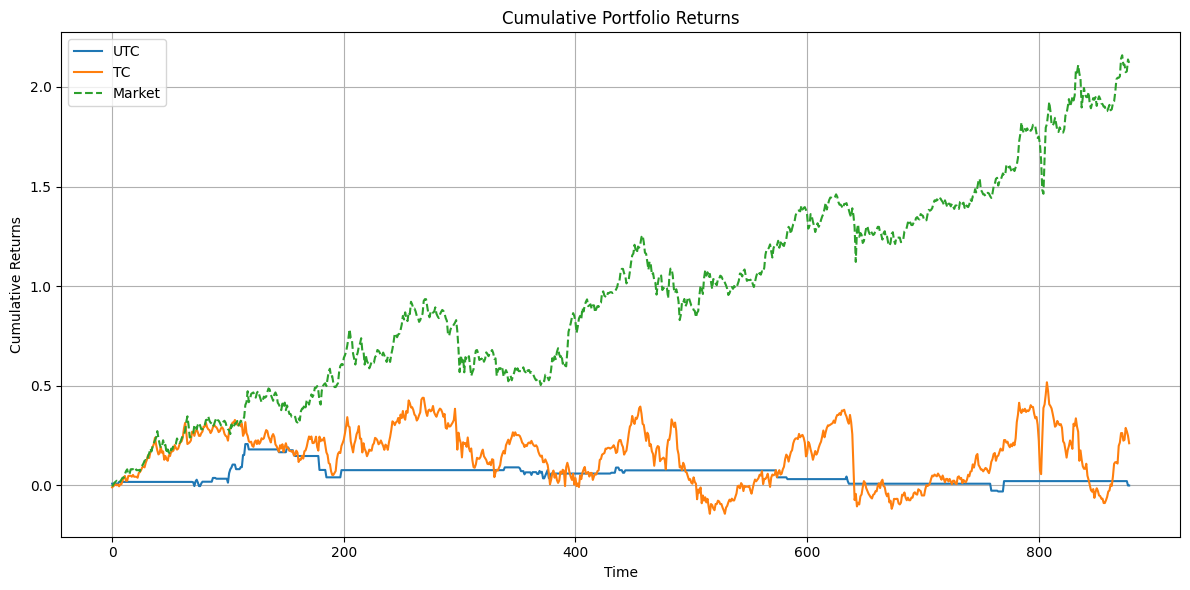

train_T 300
[Company.train] T=300, window=30,N=100
t=50/299訓練中...
t=100/299訓練中...
t=150/299訓練中...
t=200/299訓練中...
t=250/299訓練中...
[UTCMethod] 訓練完了
[UTCMethod.backtest] T=811, window=30


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


[Company.train] T=300, window=30,N=100
t=50/299訓練中...
t=100/299訓練中...
t=150/299訓練中...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


t=200/299訓練中...
t=250/299訓練中...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


[UTCMethod] 訓練完了
[UTCMethod.backtest] T=811, window=30


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


指標            UTC       TC   Market
--------------------------------------------------
AR          0.15    0.66    0.57
RISK        0.21    0.49    0.49
SR          0.73    1.34    1.16
MDD     -879993162.08   -4.33   -9.50
CR          0.00    0.15    0.06


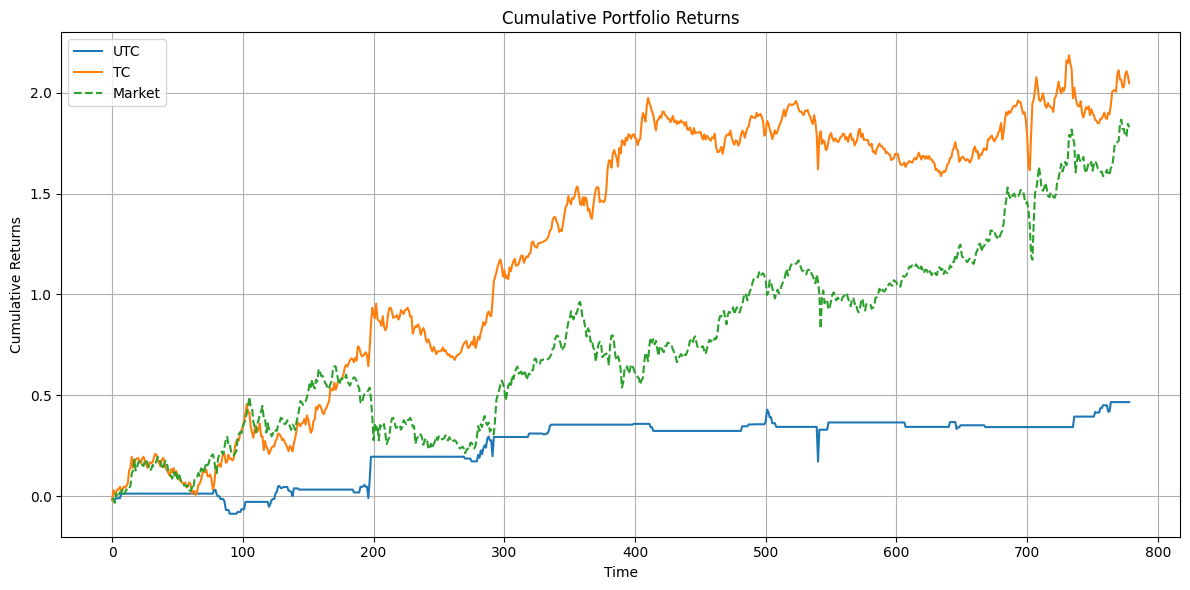

train_T 400
[Company.train] T=400, window=30,N=100
t=50/399訓練中...
t=100/399訓練中...
t=150/399訓練中...
t=200/399訓練中...
t=250/399訓練中...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


t=300/399訓練中...
t=350/399訓練中...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


[UTCMethod] 訓練完了
[UTCMethod.backtest] T=711, window=30
[Company.train] T=400, window=30,N=100
t=50/399訓練中...
t=100/399訓練中...
t=150/399訓練中...
t=200/399訓練中...
t=250/399訓練中...
t=300/399訓練中...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


t=350/399訓練中...
[UTCMethod] 訓練完了
[UTCMethod.backtest] T=711, window=30
指標            UTC       TC   Market
--------------------------------------------------
AR          0.17    0.27    0.53
RISK        0.19    0.51    0.50
SR          0.88    0.54    1.06
MDD        -0.96  -24.00 -166.50
CR          0.18    0.01    0.00


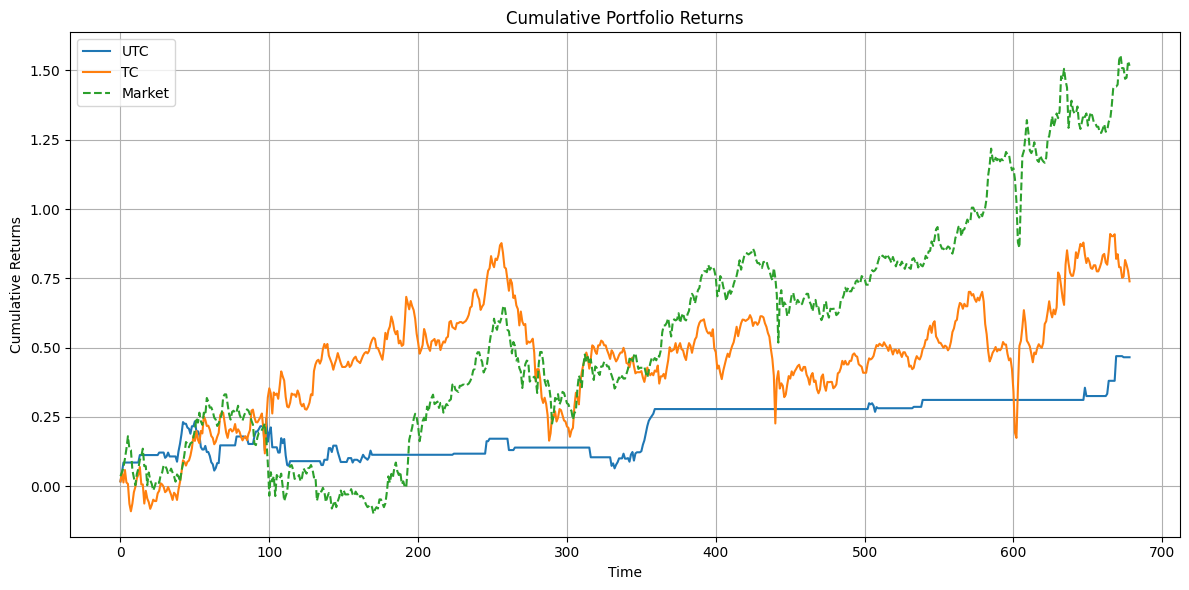

train_T 500
[Company.train] T=500, window=30,N=100
t=50/499訓練中...
t=100/499訓練中...
t=150/499訓練中...
t=200/499訓練中...
t=250/499訓練中...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


t=300/499訓練中...
t=350/499訓練中...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


t=400/499訓練中...
t=450/499訓練中...
[UTCMethod] 訓練完了
[UTCMethod.backtest] T=611, window=30


...

[Company.train] T=500, window=30,N=100
t=50/499訓練中...
t=100/499訓練中...
t=150/499訓練中...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


t=200/499訓練中...
t=250/499訓練中...
t=300/499訓練中...
t=350/499訓練中...
t=400/499訓練中...
t=450/499訓練中...
[UTCMethod] 訓練完了
[UTCMethod.backtest] T=611, window=30


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:

指標            UTC       TC   Market
--------------------------------------------------
AR         -0.08    0.15    0.59
RISK        0.22    0.51    0.51
SR         -0.37    0.29    1.15
MDD       -40.50-1559996537.11  -61.67
CR         -0.00    0.00    0.01


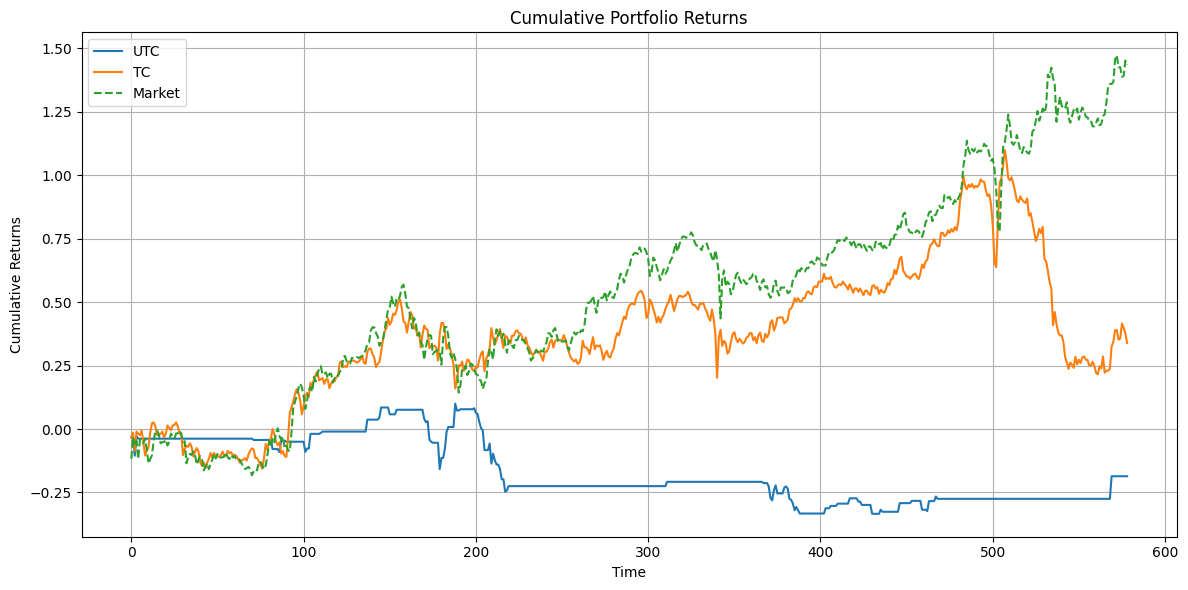

train_T 600
[Company.train] T=600, window=30,N=100
t=50/599訓練中...
t=100/599訓練中...
t=150/599訓練中...
t=200/599訓練中...
t=250/599訓練中...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


t=300/599訓練中...
t=350/599訓練中...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


t=400/599訓練中...
t=450/599訓練中...
t=500/599訓練中...
t=550/599訓練中...


...

[Company.train] T=600, window=30,N=100
t=50/599訓練中...
t=100/599訓練中...
t=150/599訓練中...
t=200/599訓練中...
t=250/599訓練中...
t=300/599訓練中...
t=350/599訓練中...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


t=400/599訓練中...
t=450/599訓練中...
t=500/599訓練中...
t=550/599訓練中...
[UTCMethod] 訓練完了
[UTCMethod.backtest] T=511, window=30


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


指標            UTC       TC   Market
--------------------------------------------------
AR          0.01    0.52    0.63
RISK        0.27    0.52    0.52
SR          0.03    1.02    1.22
MDD       -35.00   -0.97-850000001.00
CR          0.00    0.54    0.00


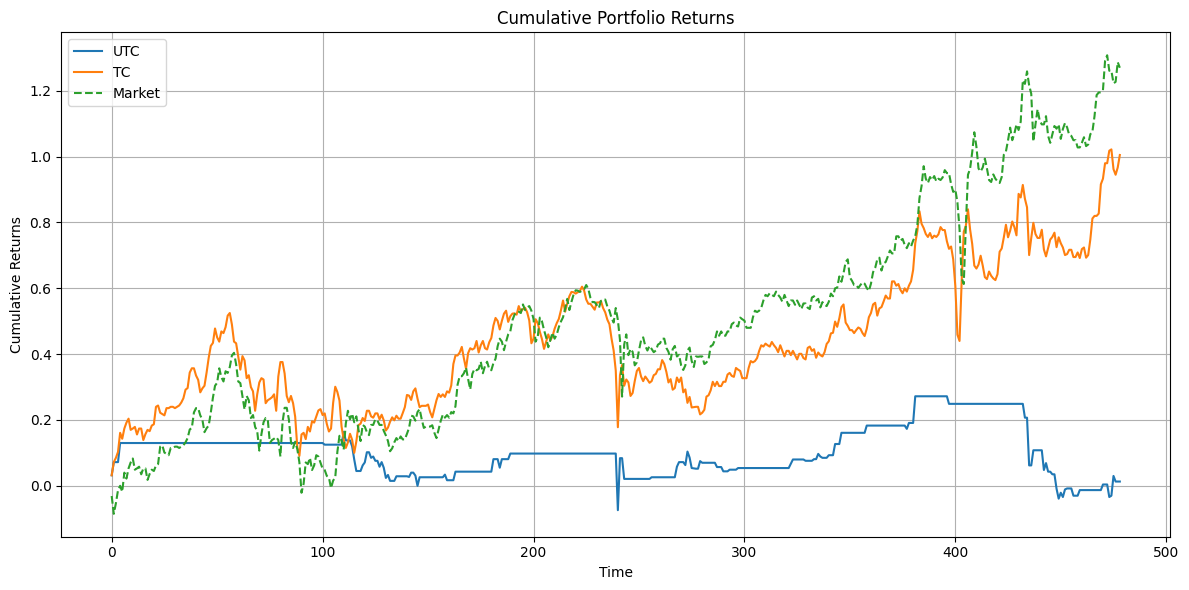

train_T 700
[Company.train] T=700, window=30,N=100
t=50/699訓練中...
t=100/699訓練中...
t=150/699訓練中...
t=200/699訓練中...
t=250/699訓練中...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


t=300/699訓練中...
t=350/699訓練中...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


t=400/699訓練中...
t=450/699訓練中...
t=500/699訓練中...
t=550/699訓練中...


...

t=200/699訓練中...
t=250/699訓練中...
t=300/699訓練中...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


t=350/699訓練中...
t=400/699訓練中...
t=450/699訓練中...
t=500/699訓練中...
t=550/699訓練中...
t=600/699訓練中...
t=650/699訓練中...
[UTCMethod] 訓練完了
[UTCMethod.backtest] T=411, window=30


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


指標            UTC       TC   Market
--------------------------------------------------
AR         -0.03    0.39    0.75
RISK        0.27    0.52    0.52
SR         -0.13    0.76    1.44
MDD        -0.95   -2.00   -3.44
CR         -0.04    0.20    0.22


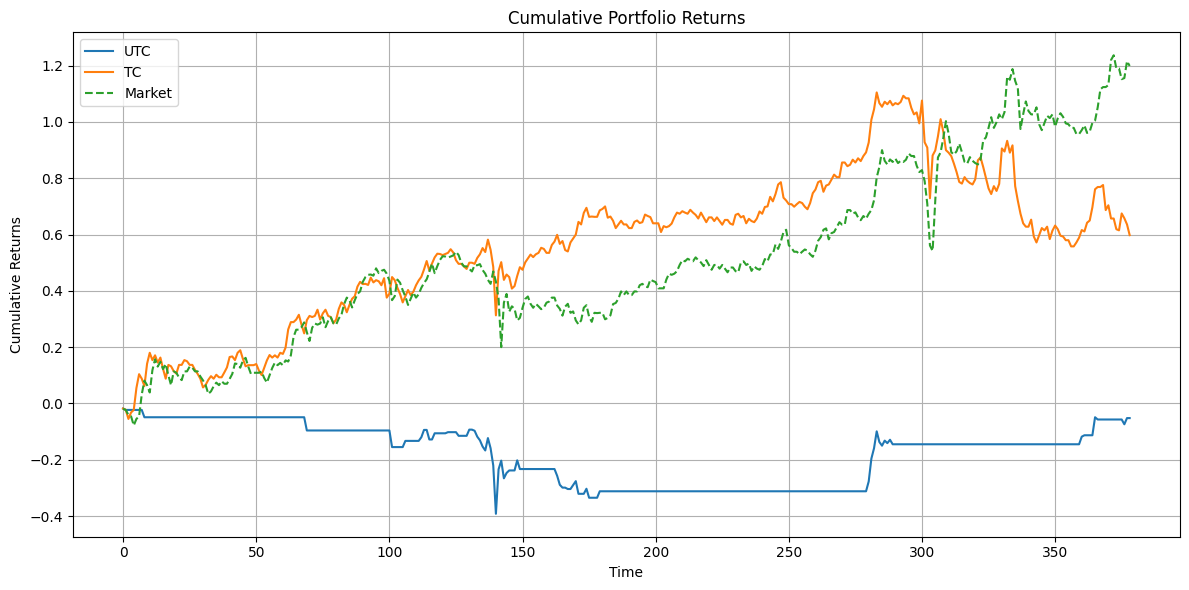

train_T 800
[Company.train] T=800, window=30,N=100
t=50/799訓練中...
t=100/799訓練中...
t=150/799訓練中...
t=200/799訓練中...
t=250/799訓練中...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


t=300/799訓練中...
t=350/799訓練中...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


t=400/799訓練中...
t=450/799訓練中...
t=500/799訓練中...
t=550/799訓練中...


...

t=600/799訓練中...
t=650/799訓練中...
t=700/799訓練中...
t=750/799訓練中...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


[UTCMethod] 訓練完了
[UTCMethod.backtest] T=311, window=30
[Company.train] T=800, window=30,N=100
t=50/799訓練中...
t=100/799訓練中...
t=150/799訓練中...
t=200/799訓練中...
t=250/799訓練中...
t=300/799訓練中...
t=350/799訓練中...
t=400/799訓練中...
t=450/799訓練中...
t=500/799訓練中...
t=550/799訓練中...
t=600/799訓練中...
t=650/799訓練中...
t=700/799訓練中...
t=750/799訓練中...
[UTCMethod] 訓練完了
[UTCMethod.backtest] T=311, window=30


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


指標            UTC       TC   Market
--------------------------------------------------
AR         -0.23   -0.22    0.60
RISK        0.29    0.56    0.56
SR         -0.79   -0.39    1.08
MDD       -38.50  -68.50-2610000001.00
CR         -0.01   -0.00    0.00


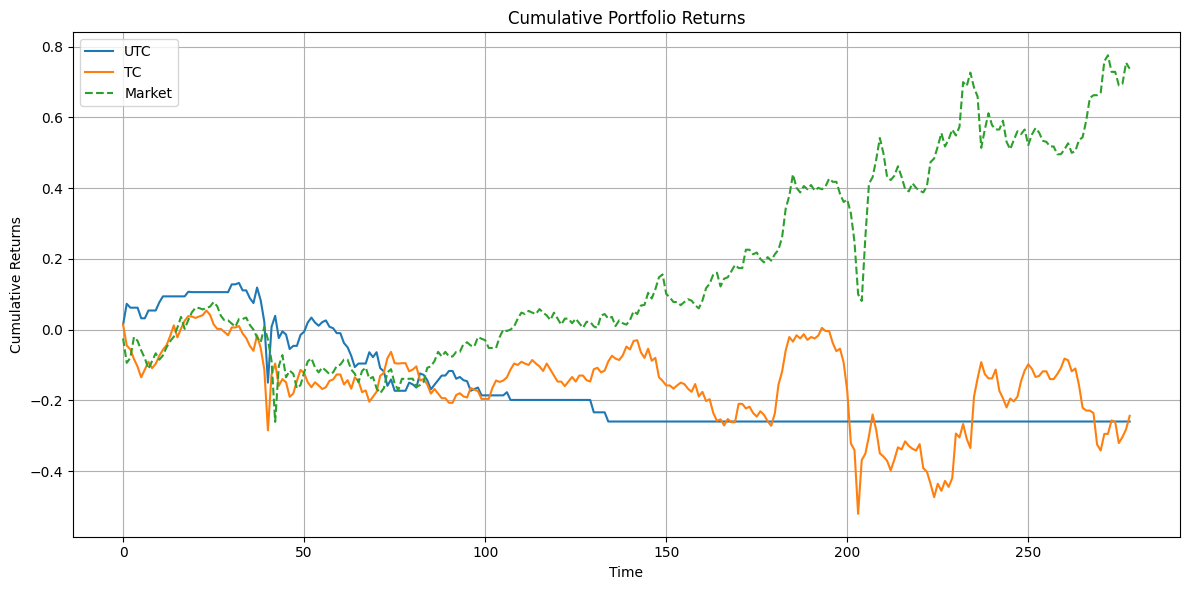

train_T 900
[Company.train] T=900, window=30,N=100
t=50/899訓練中...
t=100/899訓練中...
t=150/899訓練中...
t=200/899訓練中...
t=250/899訓練中...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


t=300/899訓練中...
t=350/899訓練中...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


t=400/899訓練中...
t=450/899訓練中...
t=500/899訓練中...
t=550/899訓練中...


...

t=550/899訓練中...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


t=600/899訓練中...
t=650/899訓練中...
t=700/899訓練中...
t=750/899訓練中...
t=800/899訓練中...
t=850/899訓練中...
[UTCMethod] 訓練完了
[UTCMethod.backtest] T=211, window=30


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


指標            UTC       TC   Market
--------------------------------------------------
AR         -0.43    0.64    0.97
RISK        0.29    0.58    0.58
SR         -1.47    1.10    1.69
MDD        -3.38  -48.00   -6.20
CR         -0.13    0.01    0.16


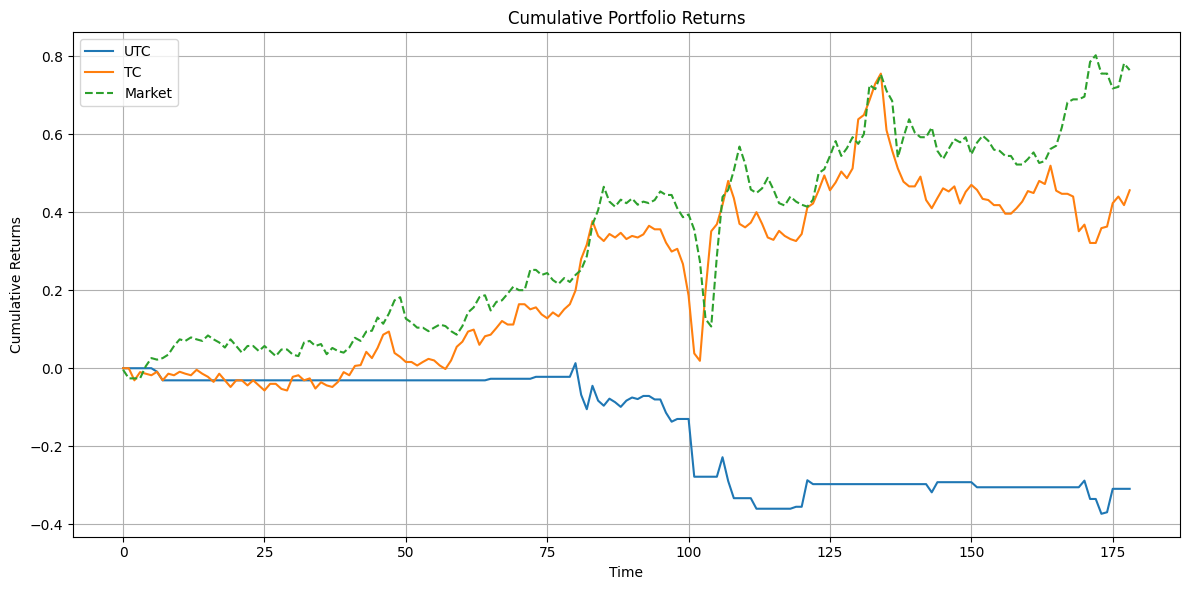

In [ ]:
for i in range(2,10):
  train_T = i*100
  print("train_T",train_T)
  experiment_market_simulation(train_T=train_T,target_stock_idx=5,n_traders=100)